# ☕ EDA — Coffee Quality Classification
### Proyecto Grupal — Clasificación de Calidad de Café

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (origen, proceso) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [1]:
# ─── Cargar de librerías  ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import warnings

In [2]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
#La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/raw/coffee_quality.csv')
df1 = pd.read_csv('../data/raw/arabica_data_cleaned.csv')

print(f'✅ Datasets cargados correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'📊 Dimensiones df1: {df1.shape[0]} filas x {df1.shape[1]} columnas')

✅ Datasets cargados correctamente
📊 Dimensiones df: 207 filas x 41 columnas
📊 Dimensiones df1: 1311 filas x 44 columnas


In [3]:
# MIO
# Antes de fusionar los datasets ver que columnas quitar o cambiar nombre
df_ordenado = df[sorted(df.columns)]
df_ordenado.columns

Index(['Acidity', 'Aftertaste', 'Altitude', 'Aroma', 'Bag Weight', 'Balance',
       'Body', 'Category One Defects', 'Category Two Defects',
       'Certification Address', 'Certification Body', 'Certification Contact',
       'Clean Cup', 'Color', 'Company', 'Country of Origin', 'Defects',
       'Expiration', 'Farm Name', 'Flavor', 'Grading Date', 'Harvest Year',
       'ICO Number', 'ID', 'In-Country Partner', 'Lot Number', 'Mill',
       'Moisture Percentage', 'Number of Bags', 'Overall', 'Owner',
       'Processing Method', 'Producer', 'Quakers', 'Region', 'Status',
       'Sweetness', 'Total Cup Points', 'Uniformity', 'Unnamed: 0', 'Variety'],
      dtype='str')

In [4]:
df1_ordenado = df1[sorted(df1.columns)]
df1_ordenado.columns

Index(['Acidity', 'Aftertaste', 'Altitude', 'Aroma', 'Bag.Weight', 'Balance',
       'Body', 'Category.One.Defects', 'Category.Two.Defects',
       'Certification.Address', 'Certification.Body', 'Certification.Contact',
       'Clean.Cup', 'Color', 'Company', 'Country.of.Origin', 'Cupper.Points',
       'Expiration', 'Farm.Name', 'Flavor', 'Grading.Date', 'Harvest.Year',
       'ICO.Number', 'In.Country.Partner', 'Lot.Number', 'Mill', 'Moisture',
       'Number.of.Bags', 'Owner', 'Owner.1', 'Processing.Method', 'Producer',
       'Quakers', 'Region', 'Species', 'Sweetness', 'Total.Cup.Points',
       'Uniformity', 'Unnamed: 0', 'Variety', 'altitude_high_meters',
       'altitude_low_meters', 'altitude_mean_meters', 'unit_of_measurement'],
      dtype='str')

In [5]:
# Reemplazar '.' por espacio ' '
df1.columns = df1.columns.str.replace('.', ' ', regex=False)
df1_ordenado = df1[sorted(df1.columns)]
df1_ordenado.columns

Index(['Acidity', 'Aftertaste', 'Altitude', 'Aroma', 'Bag Weight', 'Balance',
       'Body', 'Category One Defects', 'Category Two Defects',
       'Certification Address', 'Certification Body', 'Certification Contact',
       'Clean Cup', 'Color', 'Company', 'Country of Origin', 'Cupper Points',
       'Expiration', 'Farm Name', 'Flavor', 'Grading Date', 'Harvest Year',
       'ICO Number', 'In Country Partner', 'Lot Number', 'Mill', 'Moisture',
       'Number of Bags', 'Owner', 'Owner 1', 'Processing Method', 'Producer',
       'Quakers', 'Region', 'Species', 'Sweetness', 'Total Cup Points',
       'Uniformity', 'Unnamed: 0', 'Variety', 'altitude_high_meters',
       'altitude_low_meters', 'altitude_mean_meters', 'unit_of_measurement'],
      dtype='str')

In [6]:
# Quitar primero la columna Altitude de df1 que tiene datos muy raros, luego la cambiamos por la de "altitude_mean_meters"
df1.drop('Altitude', axis=1, inplace=True)
# Cambiar nombres de columnas con un diccionario
df1 = df1.rename(columns={'altitude_mean_meters': 'Altitude'})

In [7]:
df1.columns

Index(['Unnamed: 0', 'Species', 'Owner', 'Country of Origin', 'Farm Name',
       'Lot Number', 'Mill', 'ICO Number', 'Company', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'In Country Partner', 'Harvest Year',
       'Grading Date', 'Owner 1', 'Variety', 'Processing Method', 'Aroma',
       'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity',
       'Clean Cup', 'Sweetness', 'Cupper Points', 'Total Cup Points',
       'Moisture', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'Altitude'],
      dtype='str')

In [8]:
# Método: Filtrar df1 manteniendo solo columnas presentes en df
df1_filtrado = df1[df1.columns.intersection(df.columns)]
df1_filtrado.columns


Index(['Unnamed: 0', 'Owner', 'Country of Origin', 'Farm Name', 'Lot Number',
       'Mill', 'ICO Number', 'Company', 'Region', 'Producer', 'Number of Bags',
       'Bag Weight', 'Harvest Year', 'Grading Date', 'Variety',
       'Processing Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
       'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Total Cup Points',
       'Category One Defects', 'Quakers', 'Color', 'Category Two Defects',
       'Expiration', 'Certification Body', 'Certification Address',
       'Certification Contact', 'Altitude'],
      dtype='str')

In [9]:
df1_filtrado.shape

(1311, 35)

In [10]:
# Método: Filtrar df manteniendo solo columnas presentes en df1_filtrado
df_filtrado = df[df.columns.intersection(df1_filtrado.columns)]
df_filtrado.columns

Index(['Unnamed: 0', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill',
       'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'Harvest Year', 'Grading Date', 'Owner',
       'Variety', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste',
       'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness',
       'Total Cup Points', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact'],
      dtype='str')

In [11]:
df_filtrado.shape

(207, 35)

In [12]:
# Fusionar manteniendo solo columnas de df
# Esto toma las filas de df1, pero solo las columnas que df ya tiene.
result = pd.concat([df_filtrado, df1_filtrado], ignore_index=True)

In [13]:
df = result.copy()

---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [14]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df.head(3)

,Unnamed: 0,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,...,Sweetness,Total Cup Points,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",Diego Samuel Bermudez,...,10.0,89.33,0,0.0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,曾福森,...,10.0,87.58,0,0.0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,WU TAO CHI,...,10.0,87.42,0,0.0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"


In [15]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1518 non-null   int64  
 1   Country of Origin      1517 non-null   str    
 2   Farm Name              1160 non-null   str    
 3   Lot Number             476 non-null    str    
 4   Mill                   1205 non-null   str    
 5   ICO Number             1238 non-null   str    
 6   Company                1309 non-null   str    
 7   Altitude               1290 non-null   object 
 8   Region                 1459 non-null   str    
 9   Producer               1287 non-null   str    
 10  Number of Bags         1518 non-null   int64  
 11  Bag Weight             1518 non-null   str    
 12  Harvest Year           1471 non-null   str    
 13  Grading Date           1518 non-null   str    
 14  Owner                  1511 non-null   

In [16]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df.describe()

,Unnamed: 0,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Total Cup Points,Category One Defects,Quakers,Category Two Defects
count,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1518.000000,1517.000000,1518.000000
mean,580.591568,154.100791,7.585250,7.548979,7.425250,7.554545,7.534526,7.534763,9.854796,9.855876,9.916462,82.332833,0.386693,0.247198,3.409091
std,400.379730,150.503540,0.371444,0.393477,0.396075,0.371220,0.347302,0.391628,0.523951,0.719079,0.494403,3.373235,1.719639,1.013855,5.110187
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.000000,10.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,81.420000,0.000000,0.000000,0.000000
50%,552.500000,149.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.580000,10.000000,10.000000,10.000000,82.670000,0.000000,0.000000,2.000000
75%,931.750000,275.000000,7.750000,7.750000,7.670000,7.750000,7.750000,7.750000,10.000000,10.000000,10.000000,83.830000,0.000000,0.000000,4.000000
max,1312.000000,2240.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,90.580000,31.000000,12.000000,55.000000


In [17]:
# MIO
# Ver todas las columnas, las object también
df.describe(include='object')

C:\Users\user\AppData\Local\Temp\ipykernel_16584\3184131762.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,Producer,Bag Weight,Harvest Year,Grading Date,Owner,Variety,Processing Method,Color,Expiration,Certification Body,Certification Address,Certification Contact
count,1517,1160,476,1205,1238,1309,1290.0,1459,1287,1518,1471,1518,1511,1311,1361,1251,1518,1518,1518,1518
unique,37,728,407,607,906,341,298.0,461,837,72,52,633,385,62,12,15,632,35,51,48
top,Mexico,various,1,beneficio ixchel,0,"unex guatemala, s.a.",1200.0,huila,La Plata,1 kg,2012,"November 15th, 2022",juan luis alvarado romero,Caturra,Washed / Wet,Green,"November 15th, 2023",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660
freq,240,47,29,90,67,86,66.0,112,30,341,352,40,155,283,936,850,40,299,293,295


In [18]:
# Ver el nombre de todas las columnas disponibles
df.columns

Index(['Unnamed: 0', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill',
       'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'Harvest Year', 'Grading Date', 'Owner',
       'Variety', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste',
       'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness',
       'Total Cup Points', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact'],
      dtype='str')

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [19]:
# Contar valores nulos por columna (isnull().sum())
df.isnull().sum()

Unnamed: 0                  0
Country of Origin           1
Farm Name                 358
Lot Number               1042
Mill                      313
ICO Number                280
Company                   209
Altitude                  228
Region                     59
Producer                  231
Number of Bags              0
Bag Weight                  0
Harvest Year               47
Grading Date                0
Owner                       7
Variety                   207
Processing Method         157
Aroma                       0
Flavor                      0
Aftertaste                  0
Acidity                     0
Body                        0
Balance                     0
Uniformity                  0
Clean Cup                   0
Sweetness                   0
Total Cup Points            0
Category One Defects        0
Quakers                     1
Color                     267
Category Two Defects        0
Expiration                  0
Certification Body          0
Certificat

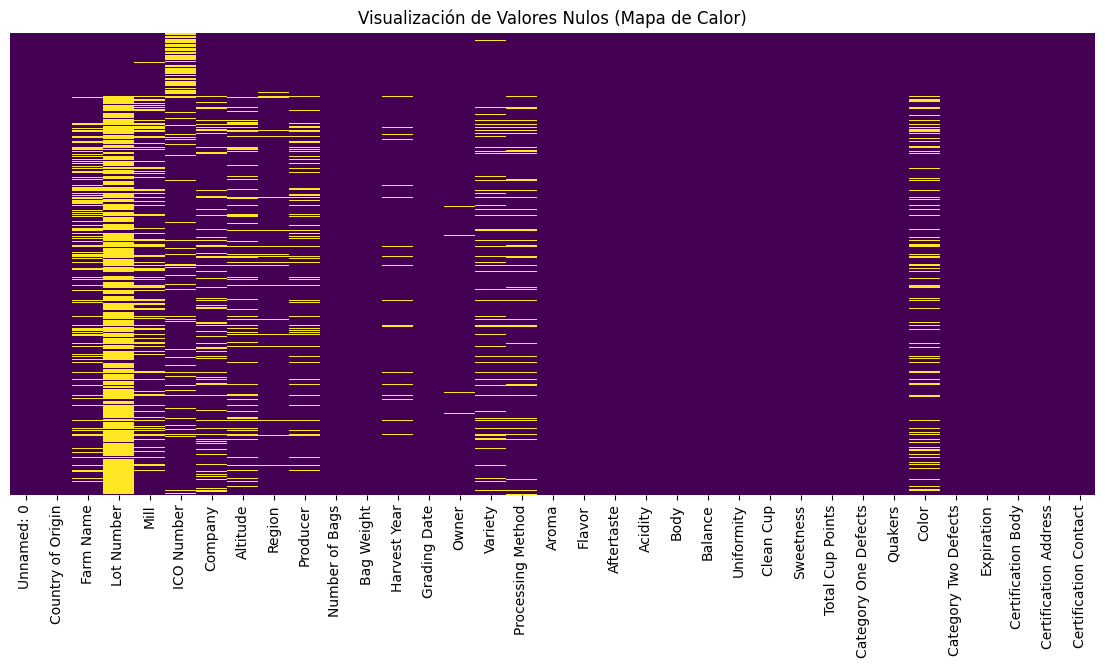

In [20]:
# Visualizar los nulos con un heatmap (Solo si lo ven necesario)

# 2. Configurar el tamaño de la figura (opcional pero recomendado)
plt.figure(figsize=(14, 6))

# 3. Crear el heatmap
# df.isnull() devuelve True donde hay nulos y False donde no
sn.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# 4. Mostrar el gráfico
plt.title("Visualización de Valores Nulos (Mapa de Calor)")
plt.show()

In [21]:
# MIO
df['Color'].value_counts()

Color
Green            850
Bluish-Green     112
green            101
Blue-Green        82
greenish          36
bluish-green      21
blue-green        12
yellow-green      10
brownish           9
pale yellow        6
yellow green       5
yellowish          4
yellow- green      1
browish-green      1
yello-green        1
Name: count, dtype: int64

In [22]:
# MIO
df['Country of Origin'].value_counts()

Country of Origin
Mexico                          240
Colombia                        202
Guatemala                       202
Brazil                          142
Taiwan                          136
United States (Hawaii)           78
Honduras                         66
Costa Rica                       59
Ethiopia                         55
Tanzania, United Republic Of     46
Thailand                         44
Nicaragua                        33
Uganda                           29
El Salvador                      28
Kenya                            27
Indonesia                        23
China                            16
Peru                             14
Vietnam                          11
Malawi                           11
Myanmar                           9
United States                     8
Laos                              6
Panama                            6
Haiti                             6
Philippines                       5
United States (Puerto Rico)       4
Burundi   

In [23]:
# MIO
df['Altitude'].value_counts()

Altitude
1200.0    66
1400.0    52
1100.0    52
1300.0    50
1500.0    44
          ..
1022.0     1
1264.0     1
3500.0     1
1280.0     1
1140.0     1
Name: count, Length: 298, dtype: int64

In [24]:
# MIO
df['Variety'].value_counts()

Variety
Caturra            283
Bourbon            243
Typica             234
Other              108
Catuai              86
                  ... 
Sumatra Lintong      1
Moka Peaberry        1
Sulawesi             1
Marigojipe           1
Pache Comun          1
Name: count, Length: 62, dtype: int64

In [25]:
# MIO
df['Processing Method'].value_counts()

Processing Method
Washed / Wet                            936
Natural / Dry                           297
Semi-washed / Semi-pulped                56
Pulped natural / honey                   39
Other                                    26
Double Anaerobic Washed                   1
Semi Washed                               1
Honey,Mossto                              1
Double Carbonic Maceration / Natural      1
Wet Hulling                               1
Anaerobico 1000h                          1
SEMI-LAVADO                               1
Name: count, dtype: int64

In [26]:
# MIO
df['Harvest Year'].value_counts()

Harvest Year
2012                        352
2014                        226
2013                        170
2015                        125
2016                        122
2021 / 2022                  99
2017                         68
2022                         48
2022 / 2023                  42
2013/2014                    29
2015/2016                    28
2011                         26
2017 / 2018                  20
2014/2015                    19
2021                         13
2009/2010                    12
2010                         10
2010-2011                     6
2016 / 2017                   6
4T/10                         4
2023                          3
March 2010                    3
2009-2010                     3
4T/2010                       3
Mayo a Julio                  3
2011/2012                     2
January 2011                  2
Abril - Julio                 2
08/09 crop                    2
2018 / 2019                   1
Sept 2009 - April 2010     

In [27]:
df.columns

Index(['Unnamed: 0', 'Country of Origin', 'Farm Name', 'Lot Number', 'Mill',
       'ICO Number', 'Company', 'Altitude', 'Region', 'Producer',
       'Number of Bags', 'Bag Weight', 'Harvest Year', 'Grading Date', 'Owner',
       'Variety', 'Processing Method', 'Aroma', 'Flavor', 'Aftertaste',
       'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness',
       'Total Cup Points', 'Category One Defects', 'Quakers', 'Color',
       'Category Two Defects', 'Expiration', 'Certification Body',
       'Certification Address', 'Certification Contact'],
      dtype='str')

In [28]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['Unnamed: 0', 'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Region', 'Producer', 'Number of Bags'], axis=1)

In [29]:
df = df.drop(['Bag Weight', 'Grading Date', 'Owner', 'Quakers', 'Expiration', 'Certification Body', 'Certification Address', 'Certification Contact'], axis=1)

---
## 🎯 BLOQUE 3 — Crear la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, si un lote de café es **Specialty** o **No Specialty**.

**¿Cómo lo creamos?**  
Usamos el estándar oficial de la **Specialty Coffee Association (SCA)**:  
- `Total Cup Points >= 82.5` → **Specialty** (calidad premium)  
- `Total Cup Points < 82.5` → **No Specialty** (calidad estándar)

**⚠️ MUY IMPORTANTE:**  
Después de crear el target, debemos **eliminar `Total.Cup.Points` del dataset**.  
Si no lo hacemos, el modelo va a hacer trampa (data leakage) porque el target viene directamente de esa columna.

In [30]:
df[df['Total Cup Points'] >= 82.5]['Total Cup Points'].count()

np.int64(837)

In [31]:
df[df['Total Cup Points'] < 82.5]['Total Cup Points'].count()

np.int64(681)

In [32]:
# Crear la columna target usando el umbral de la SCA ()
UMBRAL_SPECIALTY = 82.5

# Si "total cup point" supera el limite es Specialty sino No Specialty
df['Specialty'] = np.where(df['Total Cup Points'] >= 82.5, 'Specialty', 'No Specialty')
df.head(3)

,Country of Origin,Altitude,Harvest Year,Variety,Processing Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Total Cup Points,Category One Defects,Color,Category Two Defects,Specialty
0,Colombia,1700-1930,2021 / 2022,Castillo,Double Anaerobic Washed,8.58,8.50,8.42,8.58,8.25,8.42,10.0,10.0,10.0,89.33,0,green,3,Specialty
1,Taiwan,1200,2021 / 2022,Gesha,Washed / Wet,8.50,8.50,7.92,8.00,7.92,8.25,10.0,10.0,10.0,87.58,0,blue-green,0,Specialty
2,Laos,1300,2021 / 2022,Java,Semi Washed,8.33,8.42,8.08,8.17,7.92,8.17,10.0,10.0,10.0,87.42,0,yellowish,2,Specialty


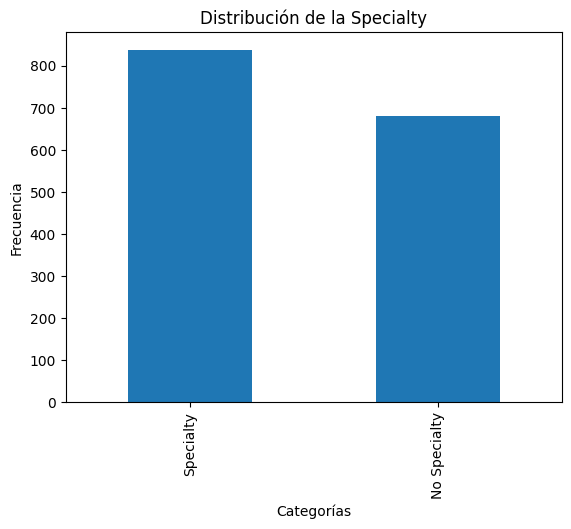

In [33]:
# Visualizar la distribución del target
# Si hay muchas más muestras de una clase que de otra = dataset DESBALANCEADO
# Un dataset desbalanceado puede engañar al modelo
# Además eliminamos Total cup Points.

# Contar valores y graficar
df['Specialty'].value_counts().plot(kind='bar')
plt.title('Distribución de la Specialty')
plt.ylabel('Frecuencia')
plt.xlabel('Categorías')
plt.show()

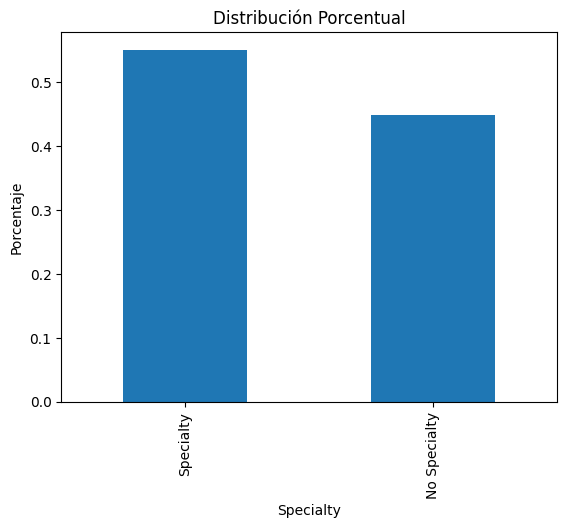

In [34]:
# MIO
df['Specialty'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución Porcentual')
plt.ylabel('Porcentaje')
plt.show()

In [35]:
# MIO
# Eliminar columna Total Cup Points
df.drop('Total Cup Points', axis=1, inplace=True)
df.head(3)

,Country of Origin,Altitude,Harvest Year,Variety,Processing Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Category One Defects,Color,Category Two Defects,Specialty
0,Colombia,1700-1930,2021 / 2022,Castillo,Double Anaerobic Washed,8.58,8.50,8.42,8.58,8.25,8.42,10.0,10.0,10.0,0,green,3,Specialty
1,Taiwan,1200,2021 / 2022,Gesha,Washed / Wet,8.50,8.50,7.92,8.00,7.92,8.25,10.0,10.0,10.0,0,blue-green,0,Specialty
2,Laos,1300,2021 / 2022,Java,Semi Washed,8.33,8.42,8.08,8.17,7.92,8.17,10.0,10.0,10.0,0,yellowish,2,Specialty


---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las puntuaciones sensoriales y si hay diferencias entre cafés Specialty y No Specialty.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada puntuación ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [ ]:
# Definir las columnas sensoriales que vamos a analizar (Las variables que tenemos en Kaggel que influyen a nuestro modelo)
# Estas son las que un Q-Grader evalúa al catar un café

# Columnas Numéricas a revisar : Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Uniformity, Clean Cup, Sweetness,
# Category One Defects, Category Two Defects
# Columnas categoricar a revisar : Color, Altitude, Variety

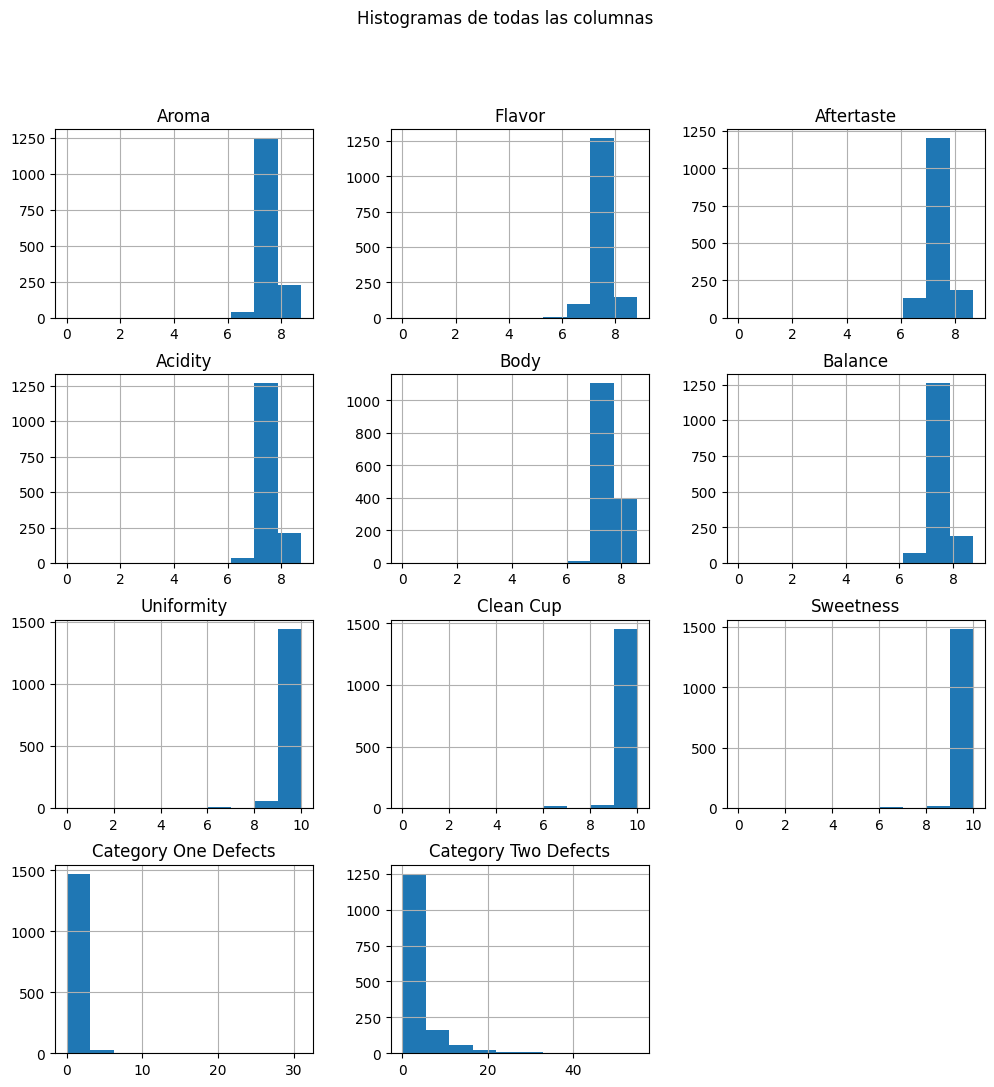

In [36]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers

# Crea un histograma para cada columna numérica del DataFrame
df.hist(bins=10, figsize=(12, 12))
plt.suptitle('Histogramas de todas las columnas')
plt.show()

In [105]:
# Agregar las gráficas que consideren necesarias.

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como el país de origen, la variedad o el método de procesado.

**Objetivo:** Entender si el origen o el proceso del café influye en la calidad final.

EStos son solo ejemplo si ven necesarios pueden hacer sus propias preguntas y explorar.

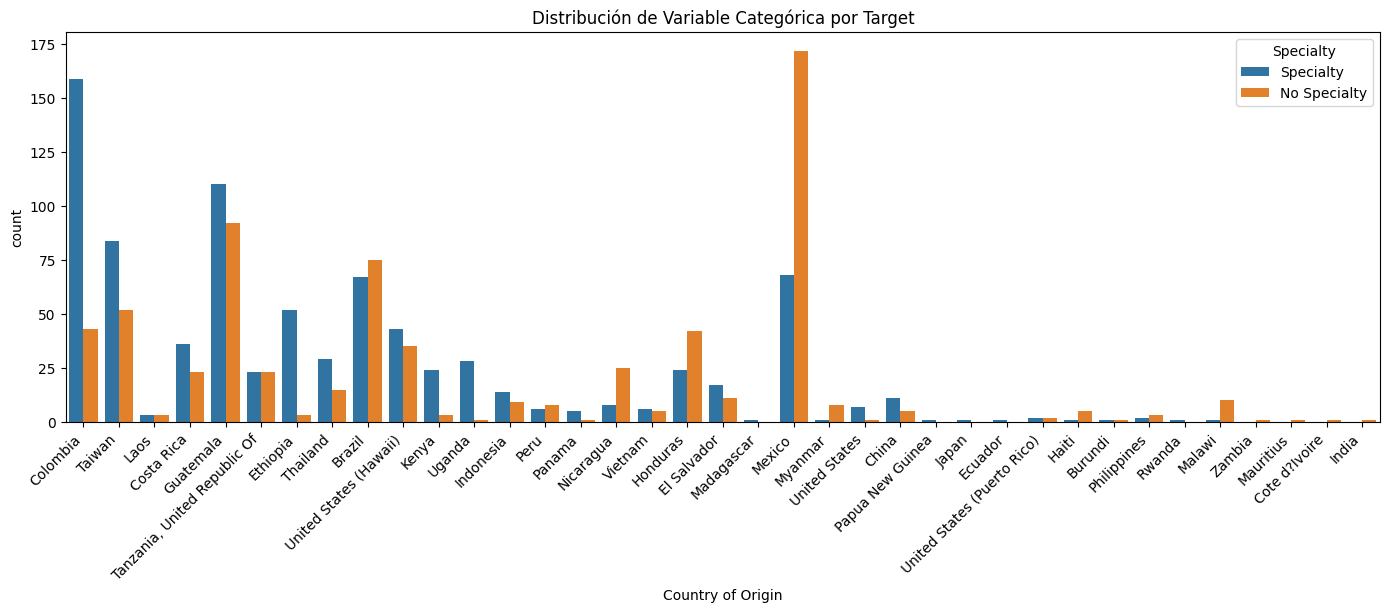

In [37]:
# ─── ANÁLISIS POR PAÍS DE ORIGEN ─────────────────────────────────────────────
# ¿Qué países producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Country of Origin', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

In [38]:
# ─── TASA DE SPECIALTY POR PAÍS ───────────────────────────────────────────────
# ¿Hay países donde una mayor proporción de su café es Specialty?

df['tasa_specialty'] = (df['Specialty'] == 'Specialty').astype(int)

tasa_por_pais = df.groupby('Country of Origin')['tasa_specialty'].mean()

tasa_por_pais_pct = tasa_por_pais * 100

tasa = pd.DataFrame(tasa_por_pais_pct)
tasa_ordenada = tasa.sort_values(by='tasa_specialty', ascending=False)

print("\nPorcentaje de Specialty por país:")
tasa_ordenada


Porcentaje de Specialty por país:


,tasa_specialty
Country of Origin,
Rwanda,100.000000
Papua New Guinea,100.000000
Madagascar,100.000000
Japan,100.000000
Ecuador,100.000000
Uganda,96.551724
Ethiopia,94.545455
Kenya,88.888889
United States,87.500000


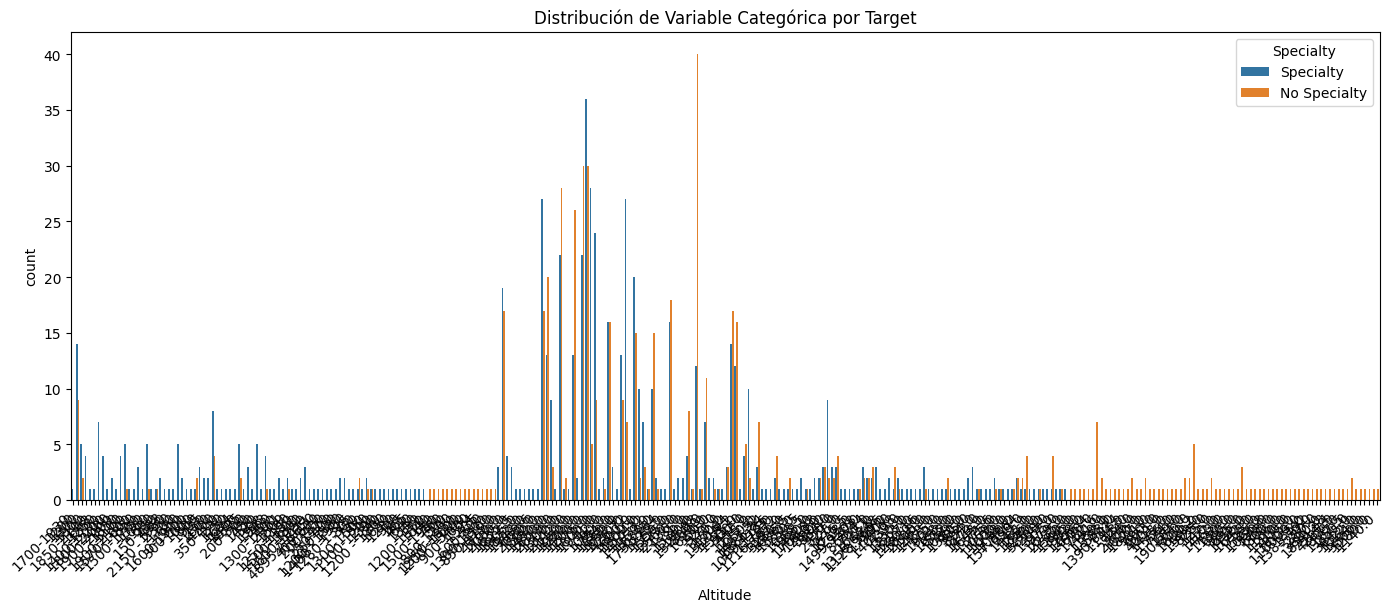

In [39]:
# MIO

# ─── ANÁLISIS POR PAÍS DE ALTITUD ─────────────────────────────────────────────
# ¿Qué altitudes producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Altitude', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

In [40]:
# MIO
df['Color'].unique()

<StringArray>
[        'green',    'blue-green',     'yellowish',  'yellow-green',
  'yellow green',      'greenish',      'brownish', 'yellow- green',
 'browish-green',  'bluish-green',   'pale yellow',   'yello-green',
         'Green',             nan,  'Bluish-Green',    'Blue-Green']
Length: 16, dtype: str

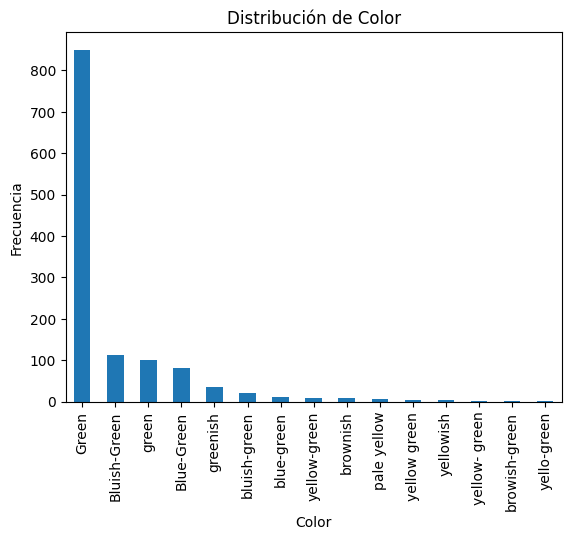

In [41]:
# MIO

df['Color'].value_counts().plot(kind='bar')
plt.title('Distribución de Color')
plt.ylabel('Frecuencia')
plt.xlabel('Color')
plt.show()

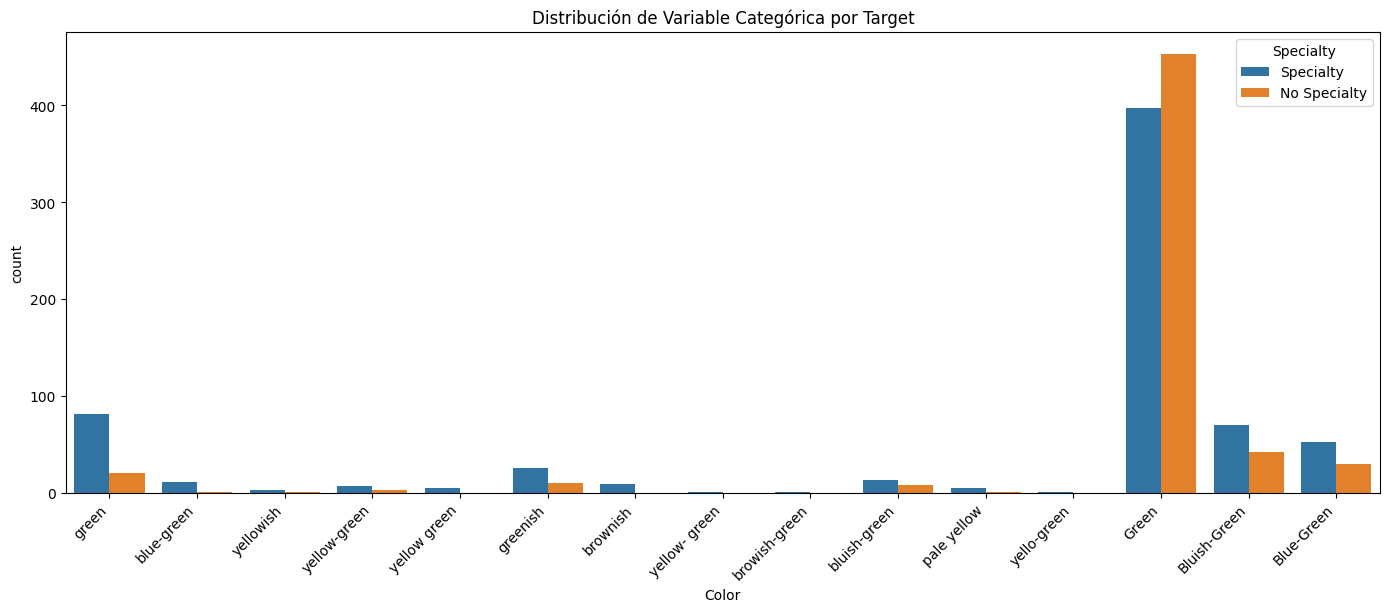

In [42]:
# MIO

# ─── ANÁLISIS POR PAÍS DE COLOR ─────────────────────────────────────────────
# ¿Qué colores producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Color', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

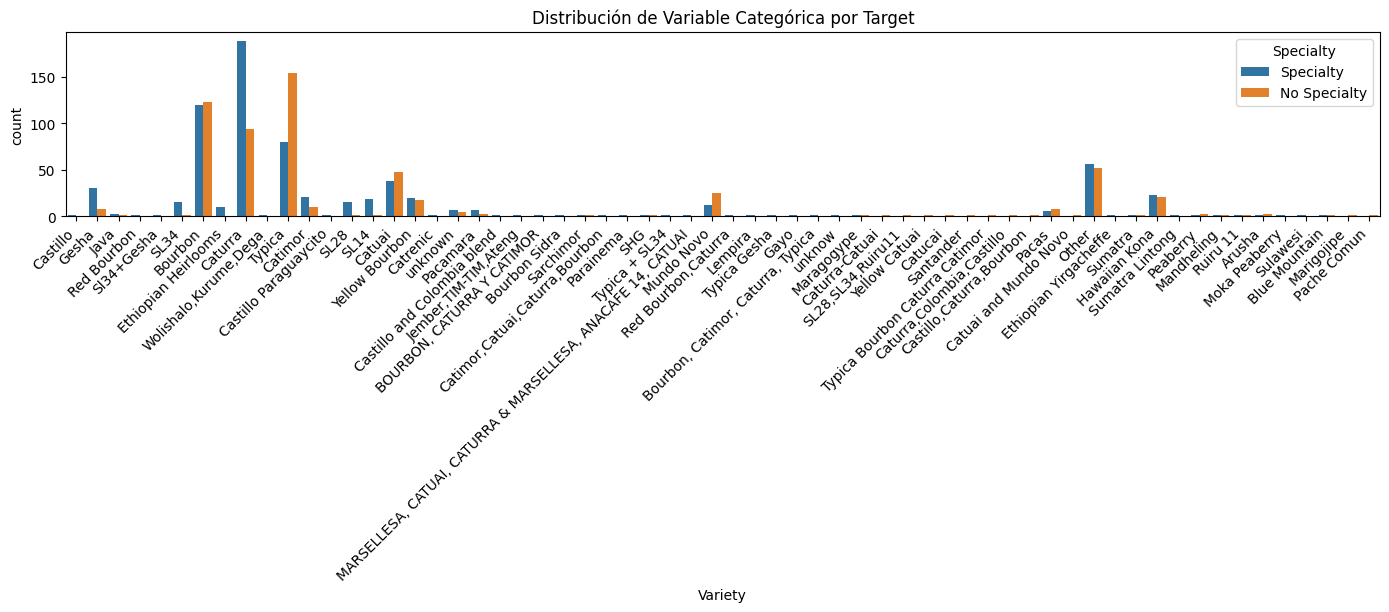

In [43]:
# MIO

# ─── ANÁLISIS POR PAÍS DE VARIEDAD ─────────────────────────────────────────────
# ¿Qué variedades producen más cafés Specialty?
plt.figure(figsize=(14, 6))
sn.countplot(x='Variety', hue='Specialty', data=df)

# 3. Rotar los nombres en el eje X
plt.xticks(rotation=45, ha='right') # 45 grados y alineado a la derecha
plt.tight_layout()

plt.title('Distribución de Variable Categórica por Target')
plt.show()

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country of Origin     1517 non-null   str    
 1   Altitude              1290 non-null   object 
 2   Harvest Year          1471 non-null   str    
 3   Variety               1311 non-null   str    
 4   Processing Method     1361 non-null   str    
 5   Aroma                 1518 non-null   float64
 6   Flavor                1518 non-null   float64
 7   Aftertaste            1518 non-null   float64
 8   Acidity               1518 non-null   float64
 9   Body                  1518 non-null   float64
 10  Balance               1518 non-null   float64
 11  Uniformity            1518 non-null   float64
 12  Clean Cup             1518 non-null   float64
 13  Sweetness             1518 non-null   float64
 14  Category One Defects  1518 non-null   int64  
 15  Color                 1251 non-n

In [45]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas

# Seleccionar solo las columnas numéricas
#df_correlacion = df.select_dtypes(include=['float64', 'int64'])
df_correlacion = df[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Category One Defects', 'Category Two Defects', 'Specialty']]

# Mapear valores: No Specialty=0, Specialty=1
df_correlacion['Specialty'] = df_correlacion['Specialty'].map({'No Specialty': 0, 'Specialty': 1})

matriz_corr = df_correlacion.corr()

print(matriz_corr)

                         Aroma    Flavor  Aftertaste   Acidity      Body  \
Aroma                 1.000000  0.818928    0.783546  0.729469  0.696328   
Flavor                0.818928  1.000000    0.897385  0.820409  0.763627   
Aftertaste            0.783546  0.897385    1.000000  0.798765  0.763245   
Acidity               0.729469  0.820409    0.798765  1.000000  0.739146   
Body                  0.696328  0.763627    0.763245  0.739146  1.000000   
Balance               0.722275  0.806640    0.827293  0.749802  0.773523   
Uniformity            0.358161  0.402651    0.394187  0.367473  0.334701   
Clean Cup             0.327755  0.388508    0.379465  0.296732  0.284430   
Sweetness             0.319318  0.354029    0.336873  0.325153  0.321530   
Category One Defects -0.080819 -0.064845   -0.084165 -0.069845 -0.020283   
Category Two Defects -0.163783 -0.210916   -0.226186 -0.151279 -0.106837   
Specialty             0.532870  0.598628    0.596478  0.541081  0.502830   

           

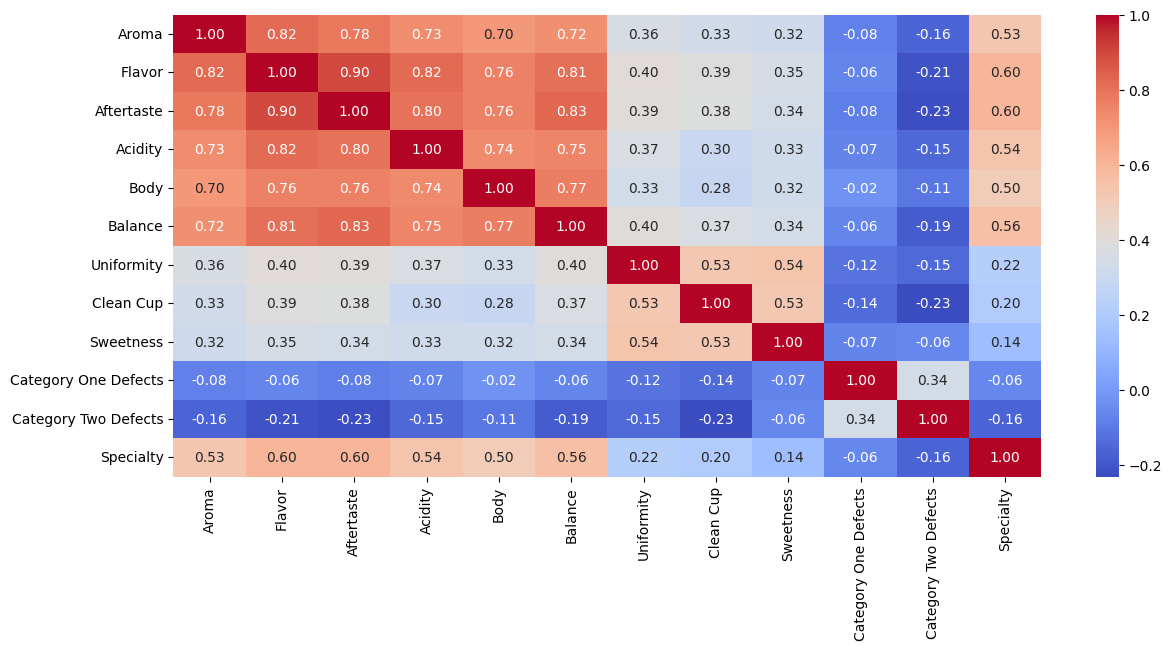

In [46]:
# 3. Pintar la matriz con Seaborn
plt.figure(figsize=(14, 6))
sn.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todos los cafés tienen entre 7 y 9 puntos de aroma y hay uno con 1.5, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

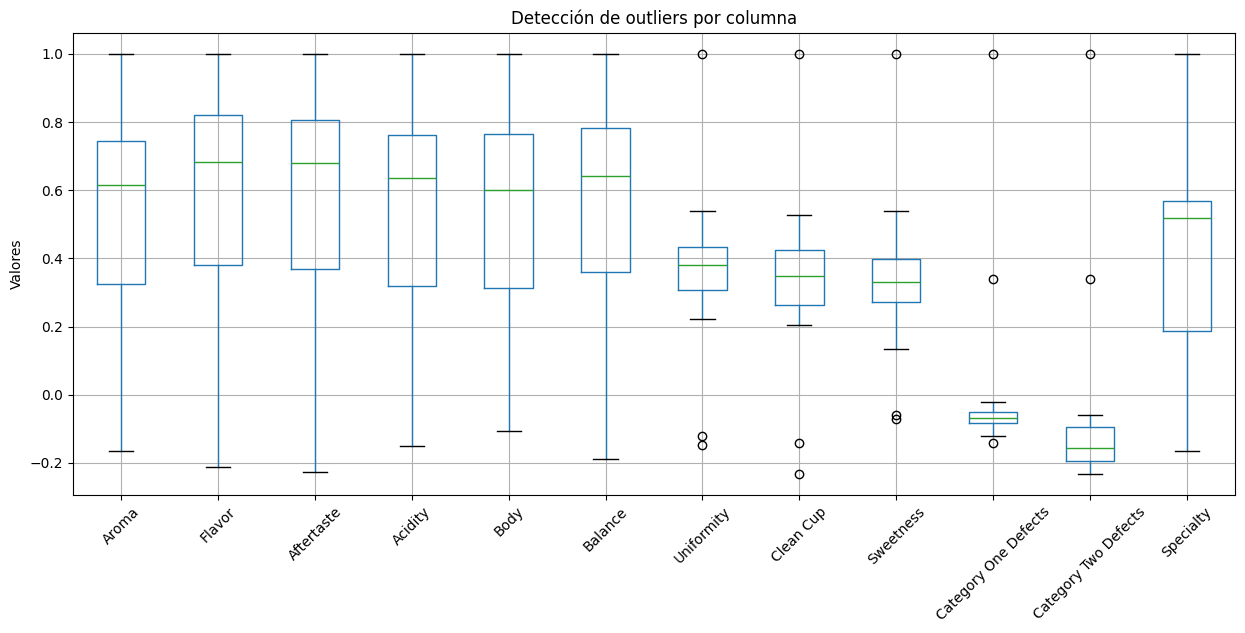

In [47]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers
# Crear el boxplot
matriz_corr.boxplot(figsize=(15, 6))
plt.title('Detección de outliers por columna')
plt.ylabel('Valores')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
# Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)

# Valorar los datos numéricos [Uniformity, Clean Cup, Sweetness, Category One Defects, Category Two Defects]

In [51]:
# MIO
# Verficar Uniformity

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Uniformity'].quantile(0.25)
Q3 = df['Uniformity'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Uniformity'] < limite_inferior) | (df['Uniformity'] > limite_superior)]

print("----------------- Uniformity --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Uniformity --------------------
Cuartil 1 (Q1): 10.0
Cuartil 3 (Q3): 10.0
IQR: 0.0
Límite Inferior: 10.0
Límite Superior: 10.0
------------------------------
Número de outliers: 185
Valores atípicos:
     Country of Origin Altitude Harvest Year        Variety Processing Method  \
85              Taiwan      800  2021 / 2022          Gesha     Natural / Dry   
119             Taiwan     1100  2021 / 2022  Typica + SL34      Washed / Wet   
215           Ethiopia   1635.0   March 2010            NaN               NaN   
221           Ethiopia   1635.0   March 2010            NaN               NaN   
224           Ethiopia      NaN    2009/2010            NaN               NaN   
...                ...      ...          ...            ...               ...   
1512          Honduras   1450.0         2014         Catuai      Washed / Wet   
1514             Haiti    350.0         2012         Typica     Natural / Dry   
1515         Nicaragua   1100.0         2016        C

In [52]:
# MIO
# Verficar Clean Cup

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Clean Cup'].quantile(0.25)
Q3 = df['Clean Cup'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Clean Cup'] < limite_inferior) | (df['Clean Cup'] > limite_superior)]

print("----------------- Clean Cup --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Clean Cup --------------------
Cuartil 1 (Q1): 10.0
Cuartil 3 (Q3): 10.0
IQR: 0.0
Límite Inferior: 10.0
Límite Superior: 10.0
------------------------------
Número de outliers: 117
Valores atípicos:
                Country of Origin Altitude Harvest Year  Variety  \
268              Papua New Guinea   1700.0         2012      NaN   
300        United States (Hawaii)      NaN    2010-2011      NaN   
461                      Thailand      NaN         2012    Other   
510   United States (Puerto Rico)   853.44         2013    Other   
536                     Guatemala   1450.0         2012  Caturra   
...                           ...      ...          ...      ...   
1513                       Mexico    900.0         2012  Bourbon   
1514                        Haiti    350.0         2012   Typica   
1515                    Nicaragua   1100.0         2016  Caturra   
1516                    Guatemala  1417.32         2012   Catuai   
1517                     Honduras  

In [55]:
df.shape

(1518, 19)

In [57]:
# Elimina 'tasa_specialty'
df = df.drop('tasa_specialty', axis=1)

In [58]:
df.head(3)

,Country of Origin,Altitude,Harvest Year,Variety,Processing Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Category One Defects,Color,Category Two Defects,Specialty
0,Colombia,1700-1930,2021 / 2022,Castillo,Double Anaerobic Washed,8.58,8.50,8.42,8.58,8.25,8.42,10.0,10.0,10.0,0,green,3,Specialty
1,Taiwan,1200,2021 / 2022,Gesha,Washed / Wet,8.50,8.50,7.92,8.00,7.92,8.25,10.0,10.0,10.0,0,blue-green,0,Specialty
2,Laos,1300,2021 / 2022,Java,Semi Washed,8.33,8.42,8.08,8.17,7.92,8.17,10.0,10.0,10.0,0,yellowish,2,Specialty


---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van vuestras conclusiones reales.**

In [59]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed

import os

# 1. Definir carpeta y nombre de archivo
folder_name = '../data/processed'
file_name = 'coffee_quality_clean.csv'
file_path = os.path.join(folder_name, file_name)

# 2. Guardar el DataFrame
df.to_csv(file_path, index=False, encoding='utf-8')
print(f"Archivo guardado en: {file_path}")

Archivo guardado en: ../data/processed\coffee_quality_clean.csv
